# Ovrlpy applied to vizgen receptor data map



In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import ovrlpy

In [2]:
font = {"family": "sans-serif", "weight": "normal", "size": 8}

matplotlib.rc("font", **font)

In [3]:
n_slice = 2


data_dir = Path(
    f"/dh-projects/ag-ishaque/raw_data/vizgen-merfish/vz-receptor-showcase/Slice{n_slice}/Replicate1"
)
boundaries_path = data_dir / "cell_boundaries"
coordinate_path = "../detected_transcripts.parquet"

In [4]:
import pickle

with open("../merscope_brain.pickle", "rb") as file:
    brain = pickle.load(file)

coordinate_df = brain.transcripts

signal_integrity = brain.integrity_map
signal_strength = brain.signal_map

In [5]:
doublet_df = brain.detect_doublets(min_integrity=0.5, min_signal=5, integrity_sigma=2)

In [6]:
import h5py
import tqdm
from shapely.geometry import Polygon

polygons = [[] for i in range(7)]

max_x = 0
max_y = 0

n_cell = 0
cell_ids_map = {}

boundaries = []

files = sorted(boundaries_path.iterdir())


for file in tqdm.tqdm(files, total=len(files)):
    with h5py.File(file, "r") as f:
        for cell, cell_idxs in f["featuredata"].items():
            if cell not in cell_ids_map:
                cell_ids_map[cell] = n_cell
                n_cell += 1
            cell_id = cell_ids_map[cell]
            for idx_key, idx in cell_idxs.items():
                if isinstance(idx, h5py.Dataset):
                    continue
                else:
                    idx_key_layer = int(idx_key.split("_")[-1])
                    for p in idx.values():
                        coord = p["coordinates"][0]

                        polygons[idx_key_layer].append((Polygon(coord), cell_id))

                        max_x = max(max_x, coord[:, 0].max())
                        max_y = max(max_y, coord[:, 1].max())

                        boundaries.append(pd.DataFrame(coord, columns=["x", "y"]))
                        boundaries[-1]["cell_id"] = cell_id
                        boundaries[-1]["z_index"] = idx_key_layer

boundary_df = pd.concat(boundaries)

del boundaries

100%|██████████| 1242/1242 [16:17<00:00,  1.27it/s] 


In [7]:
from math import ceil

from rasterio.features import rasterize
from rasterio.transform import from_origin

origin = ovrlpy.io.read_MERSCOPE(coordinate_path).select(("x", "y")).min()
transform = from_origin(origin["x"][0], origin["y"][0], 1, -1)

shape = (int(ceil(max_y - origin["y"][0])), int(ceil(max_x - origin["x"][0])))

boundary_df["x"] -= origin["x"][0]
boundary_df["y"] -= origin["y"][0]

segmentation_maps = {
    i: rasterize(
        p, out_shape=shape, fill=-1, all_touched=True, transform=transform, dtype=int
    )
    for i, p in enumerate(polygons)
    if len(p) > 0
}

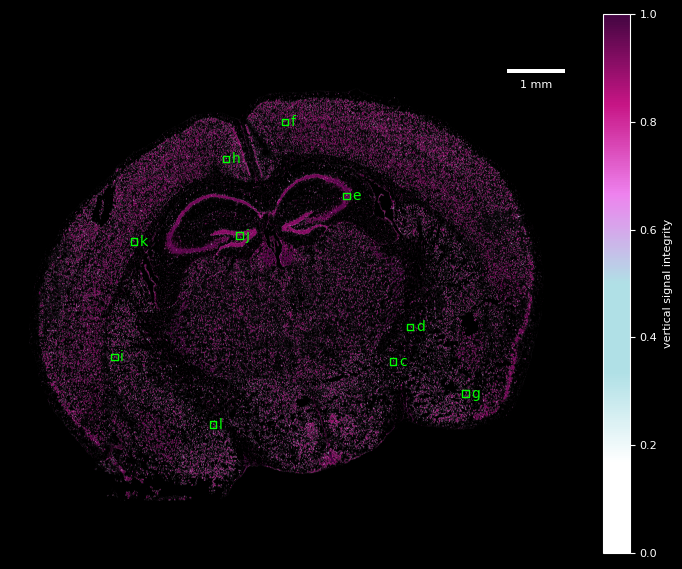

In [8]:
alphabet = "abcdefghijklmnopqrstuvwxyz"

fig = ovrlpy.plot_signal_integrity(
    brain,
    signal_threshold=3,
    histogram=False,
    scalebar={"dx": 1, "units": "um", "frameon": False, "color": "w"},
    figsize=(9, 7),
)

ax = fig.axes[0]

ax.invert_yaxis()
ax.invert_xaxis()
ax.axis("off")


for i in range(10):
    x, y = doublet_df["x", "y"].row(i)
    ax.text(x - 100, y, alphabet[i + 2], fontsize=10, color="lime", va="center")
    ax.scatter(x, y, marker="s", s=20, edgecolors="lime", facecolors="None", lw=1)


fig.savefig("receptor_integrity.svg", dpi=600)

In [9]:
import sys

sys.path.append("../..")

from utils import plot_doublet


def plot_outlines(df, x, y, window_size, ax):
    x_, _x = x - window_size, x + window_size
    y_, _y = y - window_size, y + window_size

    subset = df[df["x"].between(x_, _x) & df["y"].between(y_, _y)].copy()
    subset["x"] -= x_
    subset["y"] -= y_

    for i, (_, cell) in enumerate(subset.groupby("cell_id", observed=True)):
        cell_center = cell[["x", "y"]].mean()

        txt = ax.text(
            cell_center["x"],
            cell_center["y"],
            f"{i + 1}",
            fontsize=12,
            color=colors[i % len(colors)],
        )

        for _, cell_z in cell.groupby("z_index", observed=True):
            ax.plot(cell_z["x"], cell_z["y"], c=colors[i % len(colors)], lw=1)

In [10]:
window_size = 40

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]


for doublet_case in range(10):
    x, y = doublet_df["x", "y"].row(i)

    fig = plot_doublet(brain, x, y, window_size=window_size)

    ax = fig.axes[4]
    plot_outlines(boundary_df, x, y, window_size, ax)

    fig.savefig(f"receptor_doublet_case_{doublet_case+1}_segments.svg", dpi=600)
    fig.savefig(f"receptor_doublet_case_{doublet_case+1}_segments.pdf", dpi=600)